<a href="https://colab.research.google.com/github/Norah-444/Machine-Learning-Project/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Imports & Dataset Download
# ─────────────────────────────────────────────────────────────
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

sns.set()

# Download Fashion MNIST dataset from Kaggle
path = kagglehub.dataset_download("zalando-research/fashionmnist")
print("Path to dataset files:", path)
print("\nFiles available:")
for f in os.listdir(path):
    print(f"  - {f}")

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist

Files available:
  - t10k-labels-idx1-ubyte
  - t10k-images-idx3-ubyte
  - fashion-mnist_test.csv
  - fashion-mnist_train.csv
  - train-labels-idx1-ubyte
  - train-images-idx3-ubyte


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 2: Load & Explore Data
# ─────────────────────────────────────────────────────────────

# Load train and test CSV files
train_df = pd.read_csv(os.path.join(path, "fashion-mnist_train.csv"))
test_df  = pd.read_csv(os.path.join(path, "fashion-mnist_test.csv"))

print(f"Training set shape : {train_df.shape}")   # (60000, 785)
print(f"Test set shape     : {test_df.shape}")     # (10000, 785)
print(f"\nFirst 5 rows of training set:")
train_df.head()

Training set shape : (60000, 785)
Test set shape     : (10000, 785)

First 5 rows of training set:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3: Separate Features and Labels
# ─────────────────────────────────────────────────────────────

# Class name mapping (label 0–9)
class_names = [
    "T-shirt/Top",  # 0
    "Trouser",      # 1
    "Pullover",     # 2
    "Dress",        # 3
    "Coat",         # 4
    "Sandal",       # 5
    "Shirt",        # 6
    "Sneaker",      # 7
    "Bag",          # 8
    "Ankle Boot"    # 9
]

# Separate features (pixel values) from labels
X_train = train_df.drop("label", axis=1).values   # (60000, 784)
y_train = train_df["label"].values                 # (60000,)

X_test  = test_df.drop("label", axis=1).values    # (10000, 784)
y_test  = test_df["label"].values                  # (10000,)

# Normalize pixel values from 0–255 to 0.0–1.0
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nPixel range after normalization: [{X_train.min()}, {X_train.max()}]")

# Class distribution
print("\nClass distribution (training set):")
for i, name in enumerate(class_names):
    print(f"  Class {i} - {name:<15}: {np.sum(y_train == i)} samples")

X_train : (60000, 784)
y_train : (60000,)
X_test  : (10000, 784)
y_test  : (10000,)

Pixel range after normalization: [0.0, 1.0]

Class distribution (training set):
  Class 0 - T-shirt/Top    : 6000 samples
  Class 1 - Trouser        : 6000 samples
  Class 2 - Pullover       : 6000 samples
  Class 3 - Dress          : 6000 samples
  Class 4 - Coat           : 6000 samples
  Class 5 - Sandal         : 6000 samples
  Class 6 - Shirt          : 6000 samples
  Class 7 - Sneaker        : 6000 samples
  Class 8 - Bag            : 6000 samples
  Class 9 - Ankle Boot     : 6000 samples


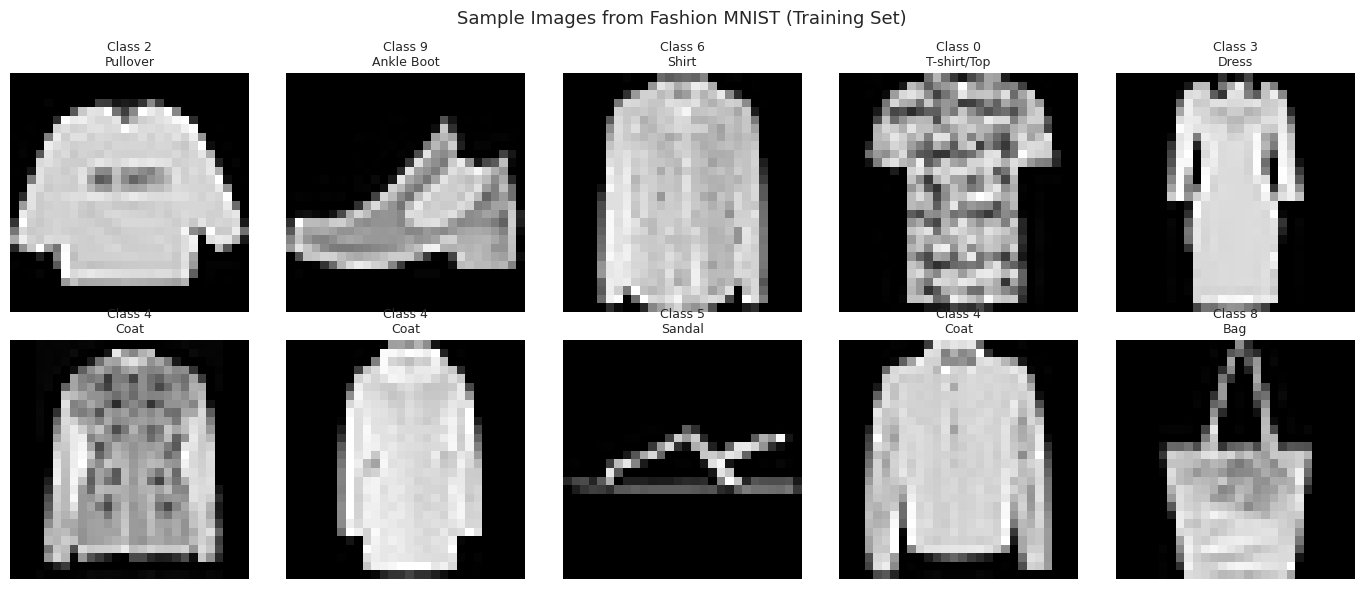

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 4: Visualize Sample Images
# ─────────────────────────────────────────────────────────────

def plot_samples(X, y, class_names, n=10):
    """Plot n sample images with their class labels."""
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for i, ax in enumerate(axes.flat):
        img = X[i].reshape(28, 28)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Class {y[i]}\n{class_names[y[i]]}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Sample Images from Fashion MNIST (Training Set)", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_samples(X_train, y_train, class_names)

In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 5: Use a Subset for SVM Training
# Note: SVM is computationally expensive on 60,000 samples.
# We use 10,000 training and 2,000 test samples for faster training.
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# Take a stratified subset
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train,
    train_size=10000,
    stratify=y_train,
    random_state=42
)

X_test_sub, _, y_test_sub, _ = train_test_split(
    X_test, y_test,
    train_size=2000,
    stratify=y_test,
    random_state=42
)

print(f"Subset sizes:")
print(f"  X_train_sub : {X_train_sub.shape}")
print(f"  X_test_sub  : {X_test_sub.shape}")

Subset sizes:
  X_train_sub : (10000, 784)
  X_test_sub  : (2000, 784)


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 6: Baseline SVM Models (RBF and Polynomial Kernels)
# ─────────────────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Train RBF kernel SVM
rbf = SVC(kernel='rbf', gamma=0.005, C=5)
rbf.fit(X_train_sub, y_train_sub)

# Train Polynomial kernel SVM
poly = SVC(kernel='poly', degree=3, C=1)
poly.fit(X_train_sub, y_train_sub)

# Predictions
rbf_pred  = rbf.predict(X_test_sub)
poly_pred = poly.predict(X_test_sub)

# Evaluation
rbf_accuracy  = accuracy_score(y_test_sub, rbf_pred)
rbf_f1        = f1_score(y_test_sub, rbf_pred, average='weighted')

poly_accuracy = accuracy_score(y_test_sub, poly_pred)
poly_f1       = f1_score(y_test_sub, poly_pred, average='weighted')

print("── Baseline SVM Results ─────────────────────────────────")
print(f"  Accuracy (RBF Kernel)        : {'%.2f' % (rbf_accuracy  * 100)}%")
print(f"  F1 Score (RBF Kernel)        : {'%.2f' % (rbf_f1        * 100)}%")
print(f"  Accuracy (Polynomial Kernel) : {'%.2f' % (poly_accuracy * 100)}%")
print(f"  F1 Score (Polynomial Kernel) : {'%.2f' % (poly_f1       * 100)}%")

── Baseline SVM Results ─────────────────────────────────
  Accuracy (RBF Kernel)        : 88.85%
  F1 Score (RBF Kernel)        : 88.71%
  Accuracy (Polynomial Kernel) : 84.00%
  F1 Score (Polynomial Kernel) : 84.03%


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 7: GridSearchCV — Best RBF Kernel with PCA Pipeline
# PCA reduces 784 features → 100 components before SVM training
# ─────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

param_grid_rbf = {
    'svc__C':     [1, 5, 10],
    'svc__gamma': [0.0005, 0.001, 0.005]
}

# Build PCA + RBF SVM pipeline
pca     = PCA(n_components=100, whiten=True, random_state=42)
svc_rbf = SVC(kernel='rbf', class_weight='balanced')
model_rbf = make_pipeline(pca, svc_rbf)

# Grid search with 5-fold cross-validation
grid_rbf = GridSearchCV(model_rbf, param_grid_rbf, cv=5, verbose=2)
%time grid_rbf.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters (RBF): {grid_rbf.best_params_}")

# Print all cross-validation scores
print("\nAll CV results:")
mean_scores = grid_rbf.cv_results_['mean_test_score']
std_scores  = grid_rbf.cv_results_['std_test_score']
params      = grid_rbf.cv_results_['params']
for mean, std, param in zip(mean_scores, std_scores, params):
    print(f"  {round(mean, 3)} ± {round(std, 3)}  for  {param}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=  11.4s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=  14.8s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=  16.8s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=  14.2s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=  11.5s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   5.9s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   6.0s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   5.4s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   6.2s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   5.1s
[CV] END .........................svc__C=1, svc__gamma=0.005; total time=   5.5s
[CV] END .........................svc__C=1, svc__

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 8: GridSearchCV — Best Polynomial Kernel with PCA Pipeline
# ─────────────────────────────────────────────────────────────

param_grid_poly = {
    'svc__C':      [0.1, 1, 5, 10],
    'svc__degree': [2, 3, 4],
    'svc__gamma':  ['scale', 'auto']
}

# Build PCA + Polynomial SVM pipeline
pca2     = PCA(n_components=100, whiten=True, random_state=42)
svc_poly = SVC(kernel='poly', class_weight='balanced')
model_poly = make_pipeline(pca2, svc_poly)

# Grid search with 5-fold cross-validation
grid_poly = GridSearchCV(model_poly, param_grid_poly, cv=5, verbose=2)
%time grid_poly.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters (Polynomial): {grid_poly.best_params_}")

# Print all cross-validation scores
print("\nAll CV results:")
mean_scores = grid_poly.cv_results_['mean_test_score']
std_scores  = grid_poly.cv_results_['std_test_score']
params      = grid_poly.cv_results_['params']
for mean, std, param in zip(mean_scores, std_scores, params):
    print(f"  {round(mean, 3)} ± {round(std, 3)}  for  {param}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ........svc__C=0.1, svc__degree=2, svc__gamma=scale; total time=   7.0s
[CV] END ........svc__C=0.1, svc__degree=2, svc__gamma=scale; total time=   8.5s
[CV] END ........svc__C=0.1, svc__degree=2, svc__gamma=scale; total time=   7.9s
[CV] END ........svc__C=0.1, svc__degree=2, svc__gamma=scale; total time=   6.8s
[CV] END ........svc__C=0.1, svc__degree=2, svc__gamma=scale; total time=   7.9s
[CV] END .........svc__C=0.1, svc__degree=2, svc__gamma=auto; total time=   7.0s
[CV] END .........svc__C=0.1, svc__degree=2, svc__gamma=auto; total time=   8.0s
[CV] END .........svc__C=0.1, svc__degree=2, svc__gamma=auto; total time=   7.6s
[CV] END .........svc__C=0.1, svc__degree=2, svc__gamma=auto; total time=   7.3s
[CV] END .........svc__C=0.1, svc__degree=2, svc__gamma=auto; total time=   8.0s
[CV] END ........svc__C=0.1, svc__degree=3, svc__gamma=scale; total time=   9.2s
[CV] END ........svc__C=0.1, svc__degree=3, svc

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 9: Evaluate Best Models from GridSearchCV
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report

# Best RBF model
best_rbf_model  = grid_rbf.best_estimator_
y_pred_rbf      = best_rbf_model.predict(X_test_sub)

best_rbf_acc = accuracy_score(y_test_sub, y_pred_rbf)
best_rbf_f1  = f1_score(y_test_sub, y_pred_rbf, average='weighted')

# Best Polynomial model
best_poly_model = grid_poly.best_estimator_
y_pred_poly     = best_poly_model.predict(X_test_sub)

best_poly_acc = accuracy_score(y_test_sub, y_pred_poly)
best_poly_f1  = f1_score(y_test_sub, y_pred_poly, average='weighted')

print("── Best Model Results ───────────────────────────────────")
print(f"  Accuracy (Best RBF Kernel)        : {'%.2f' % (best_rbf_acc  * 100)}%")
print(f"  F1 Score (Best RBF Kernel)        : {'%.2f' % (best_rbf_f1   * 100)}%")
print(f"  Accuracy (Best Polynomial Kernel) : {'%.2f' % (best_poly_acc * 100)}%")
print(f"  F1 Score (Best Polynomial Kernel) : {'%.2f' % (best_poly_f1  * 100)}%")

# Detailed classification report for best model
print("\n── Classification Report (Best RBF) ─────────────────────")
print(classification_report(y_test_sub, y_pred_rbf, target_names=class_names))

── Best Model Results ───────────────────────────────────
  Accuracy (Best RBF Kernel)        : 89.40%
  F1 Score (Best RBF Kernel)        : 89.34%
  Accuracy (Best Polynomial Kernel) : 87.55%
  F1 Score (Best Polynomial Kernel) : 87.55%

── Classification Report (Best RBF) ─────────────────────
              precision    recall  f1-score   support

 T-shirt/Top       0.82      0.85      0.83       200
     Trouser       0.99      0.98      0.99       200
    Pullover       0.82      0.80      0.81       200
       Dress       0.86      0.92      0.89       200
        Coat       0.87      0.87      0.87       200
      Sandal       0.96      0.96      0.96       200
       Shirt       0.77      0.70      0.73       200
     Sneaker       0.92      0.96      0.94       200
         Bag       0.96      0.96      0.96       200
  Ankle Boot       0.97      0.93      0.95       200

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000

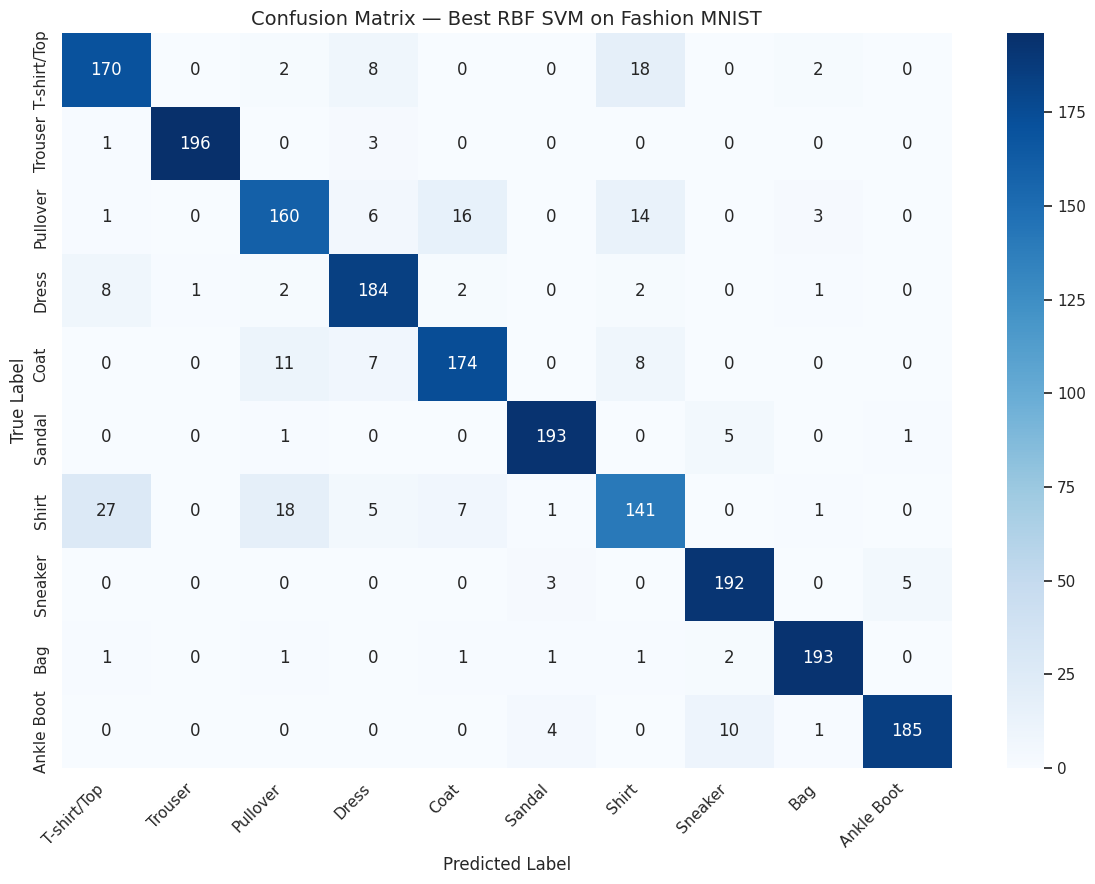

In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 10: Confusion Matrix — Best RBF Model
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_test_sub, y_pred_rbf)

plt.figure(figsize=(12, 9))
sns.heatmap(mat,
            annot=True, fmt='d', cbar=True,
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix — Best RBF SVM on Fashion MNIST", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

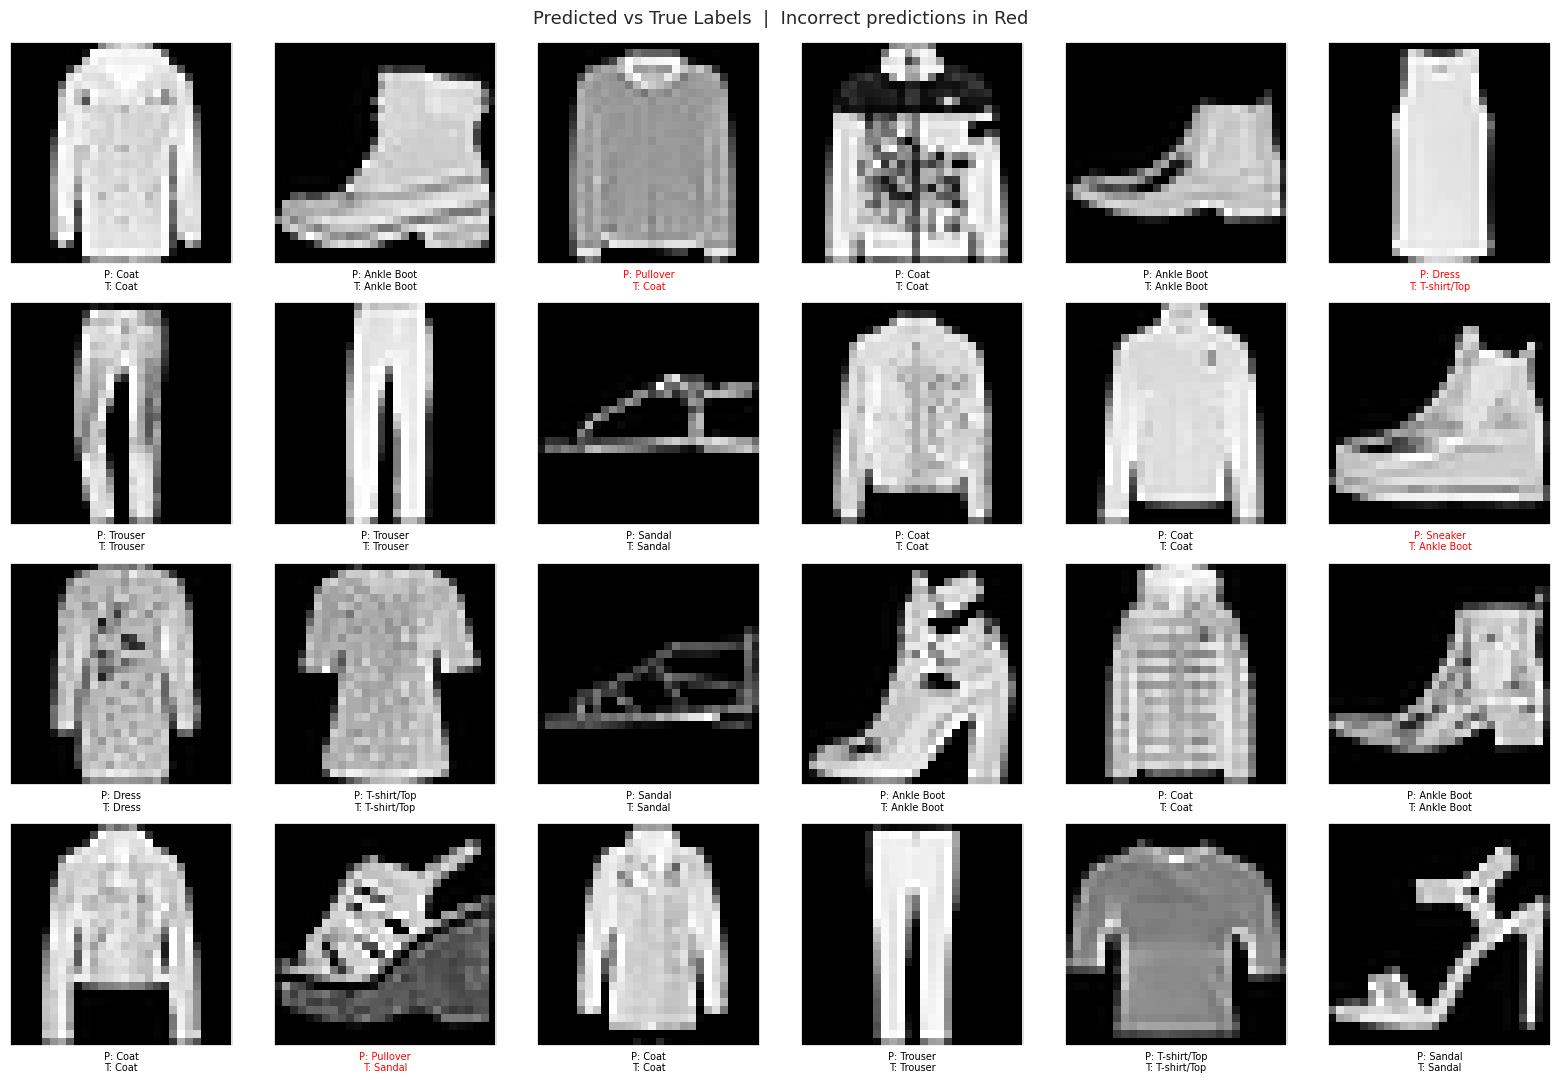

In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 11: Visualize Predictions (Correct = Black, Wrong = Red)
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(4, 6, figsize=(16, 11))
for i, ax in enumerate(axes.flat):
    img = X_test_sub[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set(xticks=[], yticks=[])
    true_label = class_names[y_test_sub[i]]
    pred_label = class_names[y_pred_rbf[i]]
    correct    = y_pred_rbf[i] == y_test_sub[i]
    ax.set_xlabel(
        f"P: {pred_label}\nT: {true_label}",
        color='black' if correct else 'red',
        fontsize=7
    )

plt.suptitle(
    "Predicted vs True Labels  |  Incorrect predictions in Red",
    fontsize=13
)
plt.tight_layout()
plt.show()